In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(2026)

In [10]:
USE_EXAMPLE_DATA = False
CSV_FILENAME = "trial_01.csv"

print("Using:", "synthetic example" if USE_EXAMPLE_DATA else CSV_FILENAME)

Using: trial_01.csv


In [11]:
if USE_EXAMPLE_DATA:
    data = example_data.copy()
else:
    data = pd.read_csv(CSV_FILENAME)

data.head()

,test_name,trial_num,sample_num,sample_time,sensor_num,sensor_reading
0,offsetTest_white,1,1,3669889232,0,675
1,offsetTest_white,1,1,3669889232,1,397
2,offsetTest_white,1,1,3669889232,2,372
3,offsetTest_white,1,1,3669889232,3,470
4,offsetTest_white,1,1,3669889232,4,683


In [12]:
WHITE_TEST_NAME = "offsetTest_white"
CHECK_TEST_NAME = "offsetTest_offwhite"
SELECTED_SENSOR = 0
SELECTED_TRIAL = 1

white_data = data.loc[data["test_name"] == WHITE_TEST_NAME].copy()
check_data = data.loc[data["test_name"] == CHECK_TEST_NAME].copy()

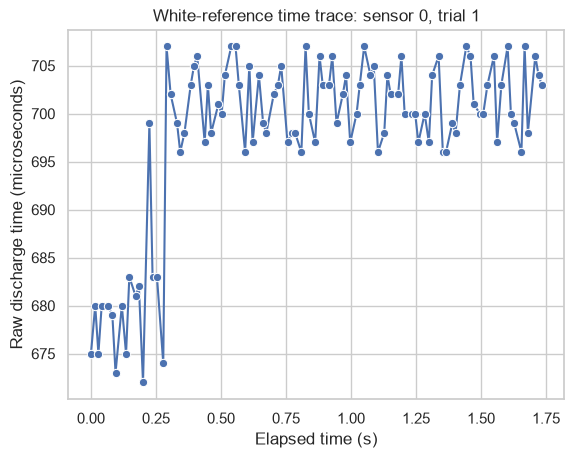

In [13]:
time_trace = white_data.loc[
    (white_data["sensor_num"] == SELECTED_SENSOR)
    & (white_data["trial_num"] == SELECTED_TRIAL)
].copy()
time_trace["elapsed_time_s"] = (
    time_trace["sample_time"] - time_trace["sample_time"].min()
) / 1_000_000

sns.lineplot(data=time_trace, x="elapsed_time_s", y="sensor_reading", marker="o")
plt.title(f"White-reference time trace: sensor {SELECTED_SENSOR}, trial {SELECTED_TRIAL}")
plt.xlabel("Elapsed time (s)")
plt.ylabel("Raw discharge time (microseconds)")
plt.show()

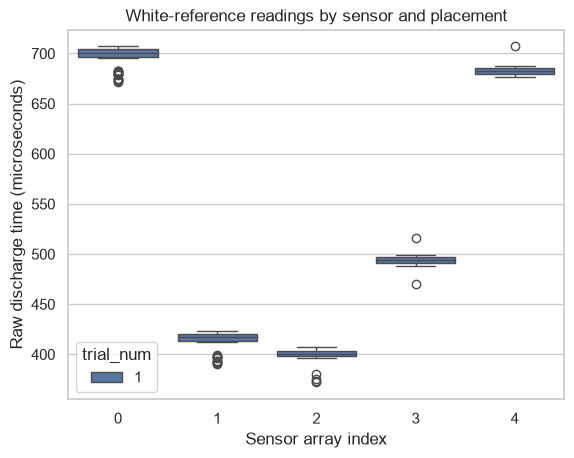

In [14]:
sns.boxplot(data=white_data, x="sensor_num", y="sensor_reading", hue="trial_num")
plt.title("White-reference readings by sensor and placement")
plt.xlabel("Sensor array index")
plt.ylabel("Raw discharge time (microseconds)")
plt.show()

In [15]:
placement_summary = (
    white_data.groupby(["sensor_num", "trial_num"], as_index=False)
    .agg(samples=("sensor_reading", "size"),
         mean_us=("sensor_reading", "mean"),
         median_us=("sensor_reading", "median"),
         variance_us2=("sensor_reading", "var"),
         sd_us=("sensor_reading", "std"))
)
placement_summary

,sensor_num,trial_num,samples,mean_us,median_us,variance_us2,sd_us
0,0,1,100,697.78,700.0,84.840000,9.210863
1,1,1,100,414.64,417.0,67.263030,8.201404
2,2,1,100,399.93,400.0,35.924343,5.993692
3,3,1,100,493.74,494.5,23.002424,4.796084
4,4,1,100,683.01,683.0,17.020101,4.125543


In [16]:
channel_reference = (
    placement_summary.groupby("sensor_num", as_index=False)
    .agg(white_reference_us=("median_us", "median"),
         between_placement_sd_us=("median_us", "std"),
         typical_within_sd_us=("sd_us", "median"))
)
common_reference_us = channel_reference["white_reference_us"].median()
channel_reference["offset_from_common_reference_us"] = (
    channel_reference["white_reference_us"] - common_reference_us
)
channel_reference

,sensor_num,white_reference_us,between_placement_sd_us,typical_within_sd_us,offset_from_common_reference_us
0,0,700.0,NaN,9.210863,205.5
1,1,417.0,NaN,8.201404,-77.5
2,2,400.0,NaN,5.993692,-94.5
3,3,494.5,NaN,4.796084,0.0
4,4,683.0,NaN,4.125543,188.5
